In [97]:
import pandas as pd
from os.path import join
import matplotlib.pyplot as plt

In [98]:
MASTER_FP = "../.outFiles/analysis/compressed/master.csv"
OUT_DATA_FOLDER_PATH = "../.outFiles/analysis/out_data"
master_df = pd.read_csv(MASTER_FP)

master_df["tx_date"]  = pd.to_datetime(master_df["tx_date"])
master_df["notif_date"]  = pd.to_datetime(master_df["notif_date"])
master_df

C:\Users\fdirham\AppData\Local\Temp\ipykernel_20820\1464853598.py:3: DtypeWarning: Columns (13,17) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv(MASTER_FP)


,p_full_name,p_chamber,p_state,p_district,p_party,asset_name,ticker,ticker_location,tx_type,owner,tx_date,notif_date,amount,asset_desc,amount_min,amount_avg,amount_max,doc_id,data_source
0,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,2012-02-27,2012-02-27,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE
1,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,2012-03-20,2012-03-20,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE
2,Alan S Lowenthal,H,California,47,D,KANSAS CITY SOUTHERN,KSU,NaN,P,SP,2012-06-06,2012-06-06,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE
3,Tom Malinowski,H,New Jersey,7,D,BioLife Solutions Inc,BLFSD,NaN,P,NaN,2012-06-19,2021-08-26,1000-15000,NaN,1001.0,8000.5,15000.0,20019374,WATCHER_HOUSE
4,Tammy Duckworth,S,Illinois,NaN,D,PROCTER GAMBLE COMPANY,PG,NaN,S,JT,2012-07-24,2012-10-05,1000-15000,SUBHOLDING OF BROKERAGE 2 USAA 8425,1001.0,8000.5,15000.0,20000923,SELF_HOUSE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54935,Pete Sessions,H,Texas,17,R,US TREASURY BOND,NaN,NaN,P,SP,2024-03-07,2024-03-08,15000-50000,NaN,15001.0,32500.5,50000.0,NaN,CAPITOL_TRADES
54936,William R Keating,H,Massachusetts,9,D,Capital One Financial Corp,COF,US,P,NaN,2024-03-07,2024-03-13,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES
54937,Mike Garcia,H,California,27,R,US TREASURY BOND,NaN,NaN,P,NaN,2024-03-08,2024-03-13,250000-500000,NaN,250001.0,375000.5,500000.0,NaN,CAPITOL_TRADES
54938,Mark E Green,H,Tennessee,7,R,NGL Energy Partners LP,NGL,US,S,NaN,2024-03-11,2024-03-14,15000-50000,NaN,15001.0,32500.5,50000.0,NaN,CAPITOL_TRADES


In [99]:
# Get total spend
def display_number(in_number):
    in_number = str(int(in_number))[::-1]

    to_return = ""
    for i, char in enumerate(in_number):
        if i and i % 3 == 0:
            to_return = "," + to_return
            
        to_return  = char + to_return
    return to_return

def get_total_spend(in_df: pd.DataFrame, print_results = True, prefix_str: str = "", ):
    min_spend = in_df["amount_min"].sum()
    avg_spend = in_df["amount_avg"].sum()
    max_spend = in_df["amount_max"].sum()
    if print_results:
        print(prefix_str + "min_spend", display_number(min_spend))
        print(prefix_str + "avg_spend", display_number(avg_spend))
        print(prefix_str + "max_spend", display_number(max_spend))
        
    return (min_spend, avg_spend, max_spend)

get_total_spend(master_df, print_results=True)

min_spend 1,179,220,903
avg_spend 2,401,448,951
max_spend 3,623,677,000


(1179220903.0, 2401448951.5, 3623677000.0)

In [100]:
# Get amount per party
mask = master_df["p_party"] == "R"
r_df = master_df[mask]

mask = master_df["p_party"] == "D"
d_df = master_df[mask]

mask = ~master_df["p_party"].isin(["R", "D"])
i_df = master_df[mask]

get_total_spend(r_df, print_results=True, prefix_str= "Republican ")
get_total_spend(d_df, print_results=True, prefix_str= "Democrat ")
get_total_spend(i_df, print_results=True, prefix_str= "Independent ")
    

Republican min_spend 635,308,829
Republican avg_spend 1,191,210,914
Republican max_spend 1,747,113,000
Democrat min_spend 543,809,027
Democrat avg_spend 1,209,764,013
Democrat max_spend 1,875,719,000
Independent min_spend 103,047
Independent avg_spend 474,023
Independent max_spend 845,000


(103047.0, 474023.5, 845000.0)

In [101]:
# Get total per state
states_list = master_df["p_state"].drop_duplicates().to_list()
state_data = []
for state in states_list:
    mask = master_df["p_state"] == state
    state_df = master_df[mask]
    res = get_total_spend(state_df, print_results=False)
    state_data.append({
        "state": state,
        "amount_min": res[0],
        "amount_avg": res[1],
        "amount_max": res[2],
    })
state_df = pd.DataFrame(state_data)
state_df = state_df.sort_values(by="amount_avg", ascending=False)

sp = join(OUT_DATA_FOLDER_PATH, "state_df.csv")
state_df.to_csv(sp)

state_df

,state,amount_min,amount_avg,amount_max
0,California,243662581.0,557983290.5,872304000.0
4,Texas,307682769.0,528618884.5,749555000.0
1,New Jersey,79281342.0,207758171.0,336235000.0
43,Tennessee,72533879.0,154429439.5,236325000.0
30,Florida,58141074.0,107313537.0,156486000.0
16,Georgia,48641870.0,105788435.0,162935000.0
12,Washington,58181585.0,105748292.5,153315000.0
24,New York,41618895.0,78237447.5,114856000.0
19,Oklahoma,42174077.0,78109538.5,114045000.0
5,Virginia,31344111.0,65070555.5,98797000.0


In [102]:
# Get amount per year
master_df["year"] = master_df["tx_date"].dt.year
master_df

YEAR_LIST = [
    2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024
]

for year in YEAR_LIST:
    year_df = master_df[master_df["year"] == year]
    get_total_spend(year_df, "year " + str(year) + " ")
    print(" ")

min_spend 4,288,598
avg_spend 10,729,299
max_spend 17,170,000
 
min_spend 5,210,646
avg_spend 12,430,323
max_spend 19,650,000
 
min_spend 6,349,783
avg_spend 14,954,891
max_spend 23,560,000
 
min_spend 13,816,186
avg_spend 32,133,093
max_spend 50,450,000
 
min_spend 11,575,190
avg_spend 25,742,595
max_spend 39,910,000
 
min_spend 18,495,895
avg_spend 43,877,947
max_spend 69,260,000
 
min_spend 182,756,295
avg_spend 390,075,647
max_spend 597,395,000
 
min_spend 282,962,740
avg_spend 568,334,870
max_spend 853,707,000
 
min_spend 283,788,647
avg_spend 587,628,823
max_spend 891,469,000
 
min_spend 312,362,473
avg_spend 602,272,736
max_spend 892,183,000
 
min_spend 57,366,406
avg_spend 112,584,703
max_spend 167,803,000
 


In [103]:
# Individual spending
indiv_spend_df = master_df.groupby("p_full_name").agg({
    "amount_min": "sum",
    "amount_avg": "sum",
    "amount_max": "sum",
}).rename_axis("p_full_name").reset_index()


indiv_spend_df = indiv_spend_df.sort_values(by="amount_avg", ascending=False).reset_index(drop=True)

indiv_spend_df

,p_full_name,amount_min,amount_avg,amount_max
0,Michael T McCaul,281556781.0,478210890.5,674865000.0
1,Ro Khanna,110525312.0,281437656.0,452350000.0
2,Josh Gottheimer,76267994.0,200591497.0,324915000.0
3,Scott H Peters,52136176.0,97450588.0,142765000.0
4,Nancy Pelosi,44425100.0,95464050.0,146503000.0
...,...,...,...,...
265,Mark Kelly,1001.0,8000.5,15000.0
266,Ruben Hinojosa,1001.0,8000.5,15000.0
267,Marcy Kaptur,1001.0,8000.5,15000.0
268,Ken Buck,1001.0,8000.5,15000.0


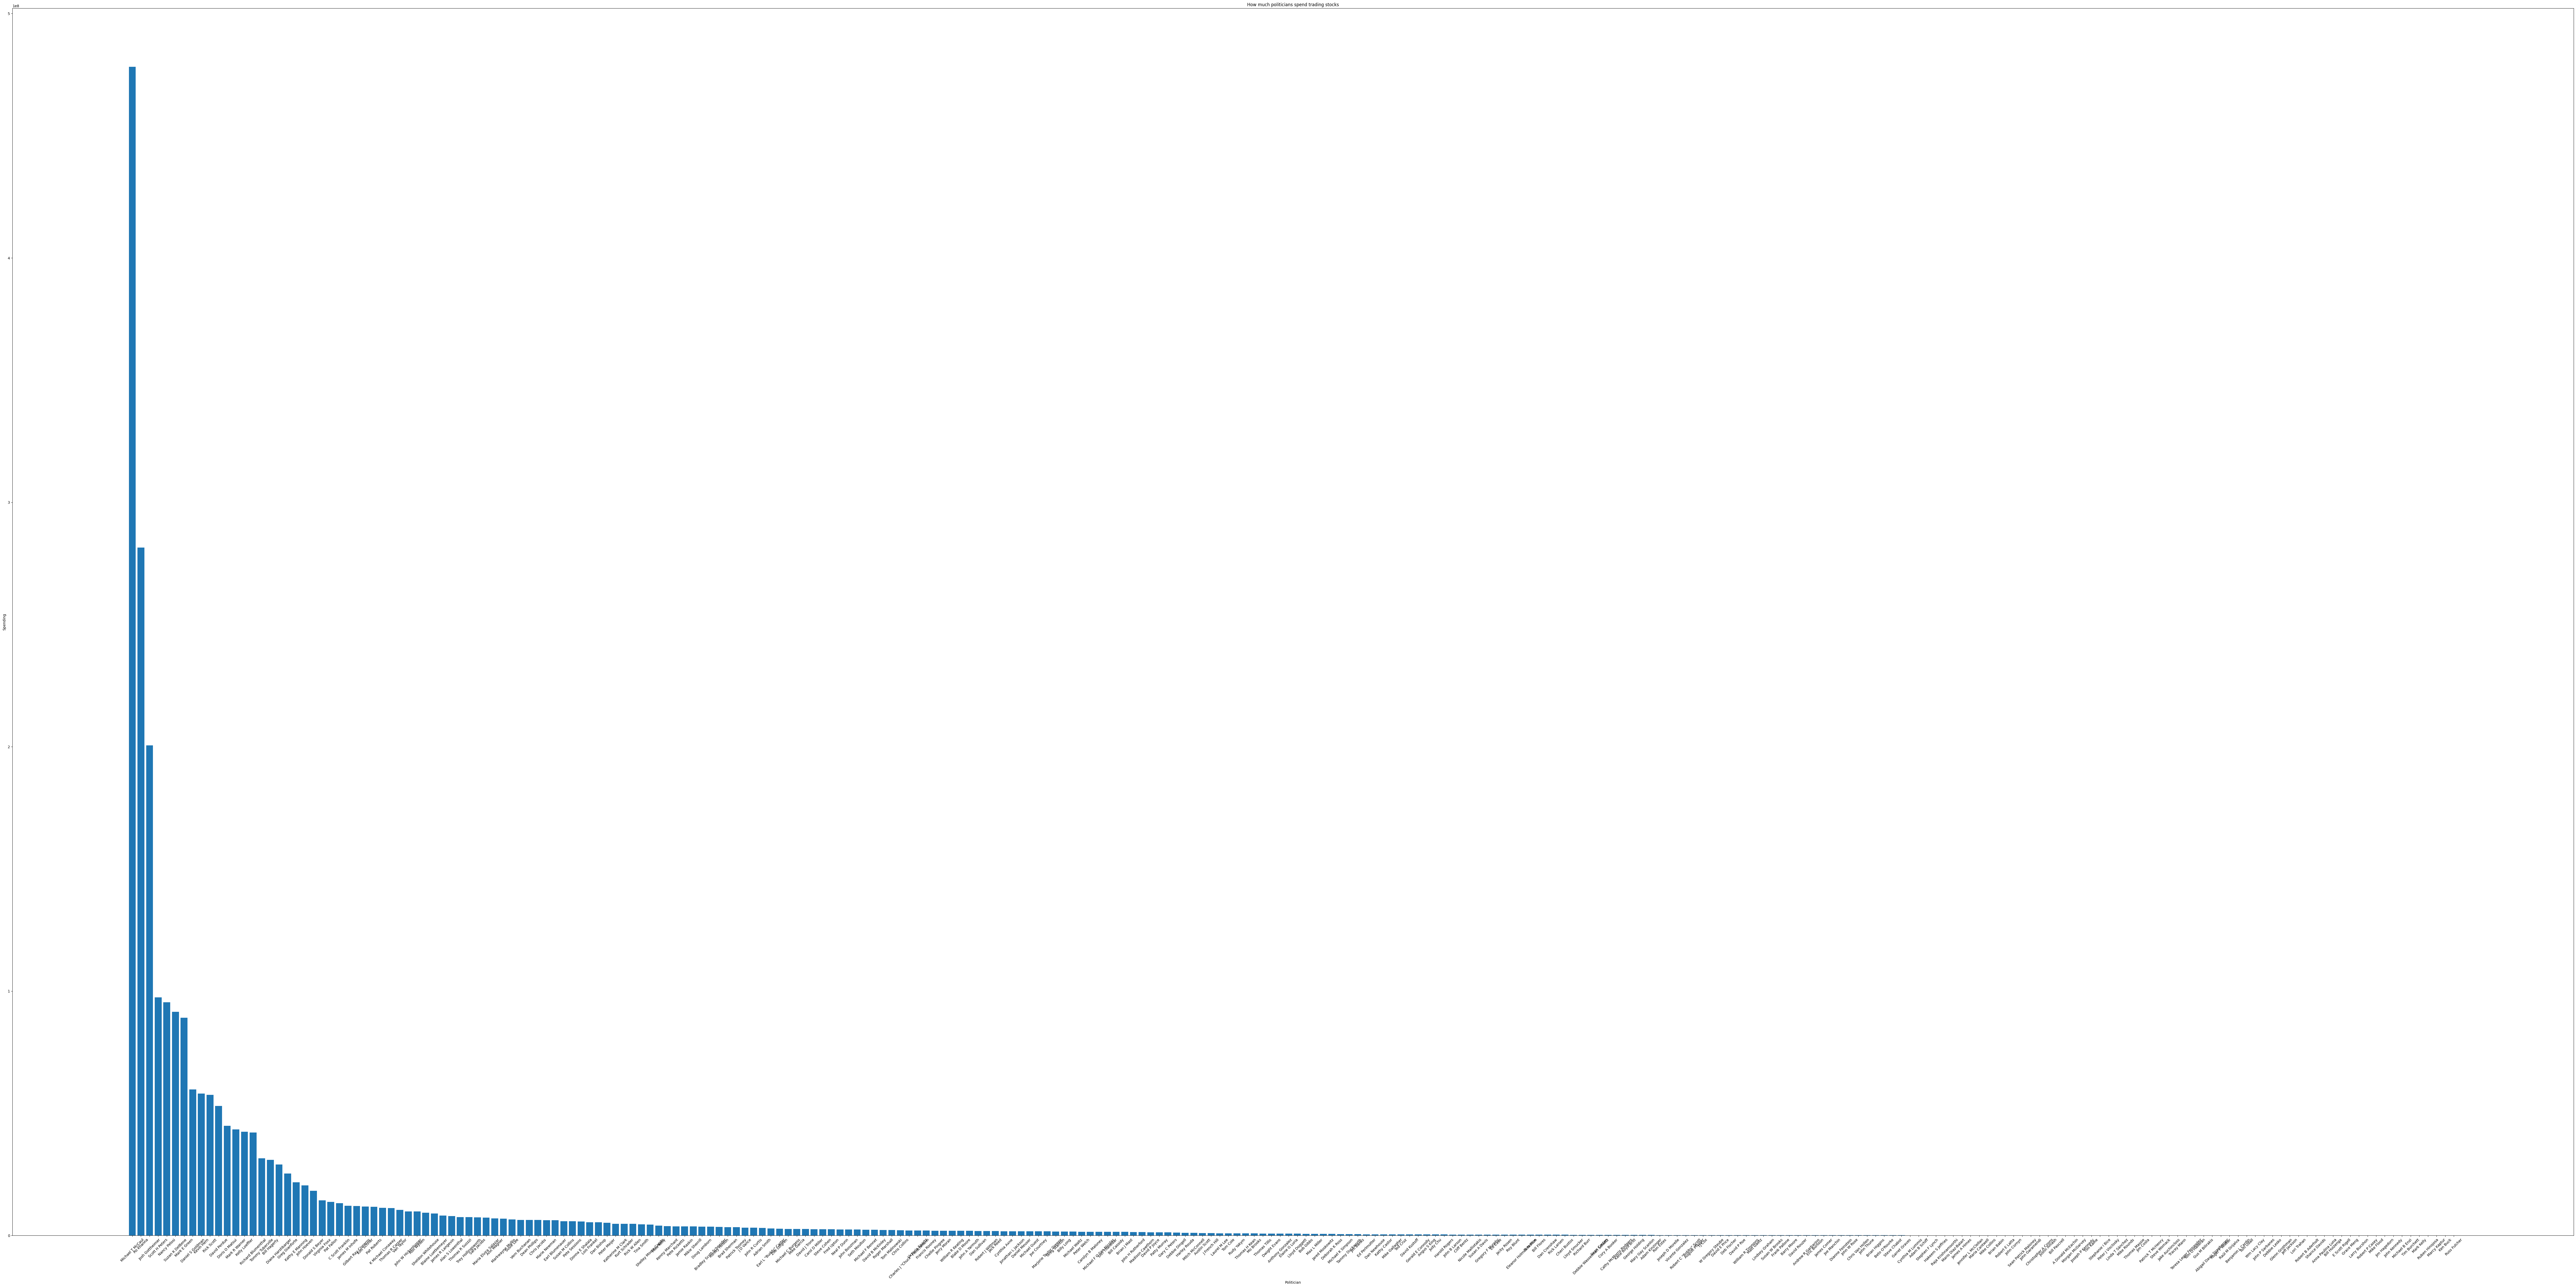

In [104]:
# Chart this
plt.figure(figsize=(100, 50))  # Adjust size as needed
full_name = indiv_spend_df["p_full_name"] 
value = indiv_spend_df["amount_avg"]

plt.bar(full_name, value )

# Adding labels and title
plt.xlabel('Politician')
plt.ylabel('Spending')
plt.title('How much politicians spend trading stocks')

# Rotating x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()  # Adjust layout
plt.show()

In [105]:
# Owner breakdown
def owner_breakdown(in_df: pd.DataFrame):
    return in_df.groupby("owner", dropna=False).size()

mask = master_df["owner"].isna()
master_df.loc[mask, "owner"] = "SELF"
owner_breakdown(master_df)

owner
DC      11210
JT      11673
SELF    15827
SP      16230
dtype: int64

In [106]:
# Assets break down
def ticker_breakdown(in_df: pd.DataFrame):
    return in_df.groupby("ticker")["amount_avg"].sum().sort_values(ascending=False)

ticker_breakdown(master_df)

ticker
MSFT     232071838.5
AAPL      37668266.0
JPM       31362649.0
GOOGL     23842227.5
NVDA      22083658.5
            ...     
RVNC          8000.5
JSGRY         8000.5
MAXN           500.0
ONVO           500.0
IGT            500.0
Name: amount_avg, Length: 3275, dtype: float64

In [107]:
# Michael McCaul
mask = master_df["p_full_name"] == "Michael T McCaul"
owner_df = master_df[mask]
owner_df

,p_full_name,p_chamber,p_state,p_district,p_party,asset_name,ticker,ticker_location,tx_type,owner,tx_date,notif_date,amount,asset_desc,amount_min,amount_avg,amount_max,doc_id,data_source,year
13242,Michael T McCaul,H,Texas,10,R,NATIONAL FUEL GAS COMPANY,NFG,NaN,P,SELF,2020-10-29,2021-01-07,15000-50000,NaN,15001.0,32500.5,50000.0,8217799,WATCHER_HOUSE,2020
13257,Michael T McCaul,H,Texas,10,R,NATIONAL FUEL GAS,NFG,NaN,P,DC,2020-10-29,2021-01-07,1000-15000,NaN,1001.0,8000.5,15000.0,8217799,WATCHER_HOUSE,2020
13280,Michael T McCaul,H,Texas,10,R,NATIONAL FUEL GAS,NFG,NaN,P,DC,2020-11-02,2021-01-07,1000-15000,NaN,1001.0,8000.5,15000.0,8217799,WATCHER_HOUSE,2020
13287,Michael T McCaul,H,Texas,10,R,BAKER HUGHES COMPANY A GE COMPANY,BKR,NaN,S,SELF,2020-11-02,2021-01-07,15000-50000,NaN,15001.0,32500.5,50000.0,8217799,WATCHER_HOUSE,2020
13288,Michael T McCaul,H,Texas,10,R,OHIO HSG FIN AGY SINGLE FAMILY,NaN,NaN,S,SELF,2020-11-02,2021-01-07,1000-15000,NaN,1001.0,8000.5,15000.0,8217799,WATCHER_HOUSE,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54470,Michael T McCaul,H,Texas,10,R,JPMORGAN 100% US TREASURY SECURITIES MONEY MAR...,NaN,US,S,DC,2024-01-30,2024-02-23,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES,2024
54471,Michael T McCaul,H,Texas,10,R,US TREASURY BILLS,NaN,NaN,S,DC,2024-01-30,2024-02-23,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES,2024
54475,Michael T McCaul,H,Texas,10,R,JPMORGAN 100% US TREASURY SECURITIES MONEY MAR...,NaN,US,S,SP,2024-01-30,2024-02-23,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES,2024
54476,Michael T McCaul,H,Texas,10,R,JPMORGAN 100% US TREASURY SECURITIES MONEY MAR...,NaN,US,S,DC,2024-01-31,2024-02-23,50000-100000,NaN,50001.0,75000.5,100000.0,NaN,CAPITOL_TRADES,2024


In [108]:
owner_breakdown(owner_df)

owner
DC      2840
JT        62
SELF     196
SP      2683
dtype: int64

In [109]:
ticker_breakdown(owner_df)

ticker
JPM      25844024.0
VMFXX    21352021.5
VTI      11064524.0
VWLUX     6348521.0
PAIDX     6000004.0
            ...    
HS          16001.0
IWD         16001.0
MBC         16001.0
LZIEX        8000.5
GBTC         8000.5
Name: amount_avg, Length: 255, dtype: float64

In [110]:
mask = owner_df["owner"] == "DC"
owner_df = owner_df[mask]
get_total_spend(owner_df)

min_spend 125,517,840
avg_spend 212,858,920
max_spend 300,200,000


(125517840.0, 212858920.0, 300200000.0)

In [111]:
mask = master_df["p_full_name"] == "Ro Khanna"
owner_df = master_df[mask]
owner_df

,p_full_name,p_chamber,p_state,p_district,p_party,asset_name,ticker,ticker_location,tx_type,owner,tx_date,notif_date,amount,asset_desc,amount_min,amount_avg,amount_max,doc_id,data_source,year
14688,Ro Khanna,H,California,17,D,CHICAGO RA O HARE INTL ARPT I GTR,NaN,NaN,S,DC,2021-01-04,2021-02-16,15000-50000,NaN,15001.0,32500.5,50000.0,8217856,WATCHER_HOUSE,2021
14689,Ro Khanna,H,California,17,D,WORTH TEX TWT AUTH REV REV SECOND IWR,NaN,NaN,S,DC,2021-01-04,2021-02-16,100000-250000,NaN,100001.0,175000.5,250000.0,8217856,WATCHER_HOUSE,2021
14690,Ro Khanna,H,California,17,D,WASHINGTON ST WAR PURP *** **** IWR,NaN,NaN,S,DC,2021-01-04,2021-02-16,15000-50000,NaN,15001.0,32500.5,50000.0,8217856,WATCHER_HOUSE,2021
14707,Ro Khanna,H,California,17,D,COLUMBIA CNTY WIS GO 4% 08/01/21 FA,NaN,NaN,P,SELF,2021-01-04,2021-02-16,15000-50000,NaN,15001.0,32500.5,50000.0,8217856,WATCHER_HOUSE,2021
14711,Ro Khanna,H,California,17,D,VIRGINIA ST PUB BLDG AUTH PUB REV 5% 08/01/21 FA,NaN,NaN,P,SELF,2021-01-04,2021-02-16,15000-50000,NaN,15001.0,32500.5,50000.0,8217856,WATCHER_HOUSE,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54898,Ro Khanna,H,California,17,D,Carter's Inc.,CRI,US,S,SP,2024-02-27,2024-03-08,50000-100000,NaN,50001.0,75000.5,100000.0,NaN,CAPITOL_TRADES,2024
54905,Ro Khanna,H,California,17,D,Topgolf Callaway Brands Corp,MODG,US,P,SP,2024-02-27,2024-03-08,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES,2024
54907,Ro Khanna,H,California,17,D,Penn National Gaming Inc,PENN,US,P,SP,2024-02-27,2024-03-08,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES,2024
54911,Ro Khanna,H,California,17,D,Topgolf Callaway Brands Corp,MODG,US,P,SP,2024-02-28,2024-03-08,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES,2024


In [112]:
owner_breakdown(owner_df)

owner
DC      7848
JT         1
SELF     112
SP      7351
dtype: int64

In [113]:
ticker_breakdown(owner_df)

ticker
IWD      5433003.5
GOOGL    4639080.0
MSFT     3568057.0
AAPL     2947532.0
SPY      2850003.5
           ...    
HLF         8000.5
CNNE        8000.5
CACC        8000.5
CASY        8000.5
ADPT        8000.5
Name: amount_avg, Length: 869, dtype: float64

In [114]:
mask = owner_df["owner"] == "DC"
owner_df = owner_df[mask]
get_total_spend(owner_df)

min_spend 45,178,848
avg_spend 130,159,424
max_spend 215,140,000


(45178848.0, 130159424.0, 215140000.0)

In [115]:
# Number with tickers
former_size = master_df.size

mask = ~master_df["ticker"].isna()
ticker_df = master_df[mask]

new_size = ticker_df.size
print("old size", display_number(former_size))
print("new size", display_number(new_size))
print("diff", display_number(former_size - new_size))

old size 1,098,800
new size 992,580
diff 106,220


In [116]:
ticker_df.groupby("ticker_location", dropna=False).size()

ticker_location
BB         3
BZ         7
CN         4
FH         1
HK        12
JP         2
LN         3
NZ         1
SS         3
UC         1
UD         1
US     33605
NaN    15986
dtype: int64

In [117]:
ticker_df[ticker_df["ticker_location"].isna()]

,p_full_name,p_chamber,p_state,p_district,p_party,asset_name,ticker,ticker_location,tx_type,owner,tx_date,notif_date,amount,asset_desc,amount_min,amount_avg,amount_max,doc_id,data_source,year
0,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,2012-02-27,2012-02-27,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012
1,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,2012-03-20,2012-03-20,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012
2,Alan S Lowenthal,H,California,47,D,KANSAS CITY SOUTHERN,KSU,NaN,P,SP,2012-06-06,2012-06-06,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012
3,Tom Malinowski,H,New Jersey,7,D,BioLife Solutions Inc,BLFSD,NaN,P,SELF,2012-06-19,2021-08-26,1000-15000,NaN,1001.0,8000.5,15000.0,20019374,WATCHER_HOUSE,2012
4,Tammy Duckworth,S,Illinois,NaN,D,PROCTER GAMBLE COMPANY,PG,NaN,S,JT,2012-07-24,2012-10-05,1000-15000,SUBHOLDING OF BROKERAGE 2 USAA 8425,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53586,Mike Collins,H,Georgia,10,R,ETHEREUM,$ETH,NaN,P,SELF,2024-01-03,2024-01-10,1000-15000,NaN,1001.0,8000.5,15000.0,NaN,CAPITOL_TRADES,2024
53634,Mike Collins,H,Georgia,10,R,ETHEREUM,$ETH,NaN,P,SELF,2024-01-08,2024-01-10,15000-50000,NaN,15001.0,32500.5,50000.0,NaN,CAPITOL_TRADES,2024
54544,Shri Thanedar,H,Michigan,13,D,LITECOIN,$LTC,NaN,S,SELF,2024-02-05,2024-02-26,15000-50000,NaN,15001.0,32500.5,50000.0,NaN,CAPITOL_TRADES,2024
54551,Shri Thanedar,H,Michigan,13,D,ETHEREUM,$ETH,NaN,S,SELF,2024-02-05,2024-02-26,100000-250000,NaN,100001.0,175000.5,250000.0,NaN,CAPITOL_TRADES,2024


In [118]:
master_df[master_df["tx_date"] < "2013"]

,p_full_name,p_chamber,p_state,p_district,p_party,asset_name,ticker,ticker_location,tx_type,owner,tx_date,notif_date,amount,asset_desc,amount_min,amount_avg,amount_max,doc_id,data_source,year
0,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,2012-02-27,2012-02-27,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012
1,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,2012-03-20,2012-03-20,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012
2,Alan S Lowenthal,H,California,47,D,KANSAS CITY SOUTHERN,KSU,NaN,P,SP,2012-06-06,2012-06-06,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012
3,Tom Malinowski,H,New Jersey,7,D,BioLife Solutions Inc,BLFSD,NaN,P,SELF,2012-06-19,2021-08-26,1000-15000,NaN,1001.0,8000.5,15000.0,20019374,WATCHER_HOUSE,2012
4,Tammy Duckworth,S,Illinois,NaN,D,PROCTER GAMBLE COMPANY,PG,NaN,S,JT,2012-07-24,2012-10-05,1000-15000,SUBHOLDING OF BROKERAGE 2 USAA 8425,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012
5,Tammy Duckworth,S,Illinois,NaN,D,CATERPILLAR INC.,CAT,NaN,P,JT,2012-07-26,2012-10-05,1000-15000,SUBHOLDING OF BROKERAGE 2 USAA 8425,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012
6,Tammy Duckworth,S,Illinois,NaN,D,PROCTER GAMBLE COMPANY,PG,NaN,S,JT,2012-08-16,2012-09-05,1000-15000,SUBHOLDING OF BROKERAGE 1 - EDJ 2718,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012
7,Thomas R Carper,S,Delaware,NaN,D,E. I. du Pont de Nemours and Company (NYSE),DD,NaN,P,SP,2012-09-13,2015-05-13,1000-15000,NaN,1001.0,8000.5,15000.0,66324d46-8701-47f3-97ba-ba1f58084f92,WATCHER_SENATE,2012
8,Alan S Lowenthal,H,California,47,D,TRUSTEES OF CALIFORNIA STATE UNIVERSITY REV. BOND,NaN,NaN,S,SP,2012-11-01,2012-11-01,15000-50000,OFFERINGS,15001.0,32500.5,50000.0,20000945,SELF_HOUSE,2012
9,Tammy Duckworth,S,Illinois,NaN,D,LOCKHEED MARTIN CORPORATION,LMT,NaN,S,JT,2012-11-13,2012-12-05,1000-15000,SUBHOLDING OF BROKERAGE 1 - EDJ 2718,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012


In [143]:
ticker_df.groupby("ticker")["amount_avg"].sum().sort_values(ascending=False).head(20)

ticker
MSFT     232071838.5
AAPL      37668266.0
JPM       31362649.0
GOOGL     23842227.5
NVDA      22083658.5
VMFXX     21352021.5
META      18535696.5
AMZN      17603211.5
ICE       16451531.5
SPY       15488036.0
NFLX      15211139.5
PYPL      14449635.5
V         13019119.0
ET        12295549.5
VTI       11088525.5
AM        10629526.0
TSLA      10549112.5
TDDXX     10467572.5
DIS        9385157.0
SHLX       9225022.0
Name: amount_avg, dtype: float64

In [142]:
mask = master_df["asset_name"].str.upper().str.replace(" ", "").str.contains("USTREASURY") & (master_df["tx_date"] > "2021")
master_df[mask]["amount_avg"].sum()

131429274.5

In [145]:
# Lateness
master_df["notif_delay"] = master_df["notif_date"] - master_df["tx_date"]
master_df.sort_values("notif_delay", ascending=False)

,p_full_name,p_chamber,p_state,p_district,p_party,asset_name,ticker,ticker_location,tx_type,owner,...,notif_date,amount,asset_desc,amount_min,amount_avg,amount_max,doc_id,data_source,year,notif_delay
3,Tom Malinowski,H,New Jersey,7,D,BioLife Solutions Inc,BLFSD,NaN,P,SELF,...,2021-08-26,1000-15000,NaN,1001.0,8000.5,15000.0,20019374,WATCHER_HOUSE,2012,3355 days
2869,Thomas R Suozzi,H,New York,3,D,Superior Industries International Inc Common S...,SUP,NaN,P,SELF,...,2022-03-03,1000-15000,NaN,1001.0,8000.5,15000.0,20020552,WATCHER_HOUSE,2017,1640 days
3201,Thomas R Suozzi,H,New York,3,D,Caterpillar Inc,CAT,NaN,P,SELF,...,2022-03-03,1000-15000,NaN,1001.0,8000.5,15000.0,20020552,WATCHER_HOUSE,2017,1548 days
3571,Thomas R Suozzi,H,New York,3,D,Boeing Company,BA,NaN,P,SELF,...,2022-03-03,15000-50000,NaN,15001.0,32500.5,50000.0,20020552,WATCHER_HOUSE,2018,1416 days
3677,Thomas R Suozzi,H,New York,3,D,Control4 Corporation,CTRL,NaN,P,SELF,...,2022-03-03,1000-15000,NaN,1001.0,8000.5,15000.0,20020552,WATCHER_HOUSE,2018,1403 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Patrick Toomey,S,Pennsylvania,NaN,R,"Provident Financial Services, Inc. (NYSE)",PFS,NaN,S,SELF,...,2014-11-05,50000-100000,NaN,50001.0,75000.5,100000.0,7d2bc1ec-5ae5-4073-aaa6-07e8cfbcd6a2,WATCHER_SENATE,2014,-25 days
14431,John B Larson,H,Connecticut,1,D,Starbucks Corporation,SBUX,NaN,S,SELF,...,2020-01-31,1000-15000,NaN,1001.0,8000.5,15000.0,20013919,WATCHER_HOUSE,2020,-322 days
1281,Susan M Collins,S,Maine,NaN,R,Cohen &amp; Steers Dividend Value A (NASDAQ),DVFAX,NaN,P,SP,...,2015-01-09,1000-15000,NaN,1001.0,8000.5,15000.0,d221805d-5957-4904-9e9b-ea15d9d65b70,WATCHER_SENATE,2015,-336 days
14549,Donald S Beyer,H,Virginia,8,D,Berkshire Hathaway Inc. New,BRK.B,NaN,P,JT,...,2020-01-02,1000-15000,NaN,1001.0,8000.5,15000.0,20013832,WATCHER_HOUSE,2020,-357 days


In [147]:
master_df.head(50)

,p_full_name,p_chamber,p_state,p_district,p_party,asset_name,ticker,ticker_location,tx_type,owner,...,notif_date,amount,asset_desc,amount_min,amount_avg,amount_max,doc_id,data_source,year,notif_delay
0,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,...,2012-02-27,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012,0 days
1,Alan S Lowenthal,H,California,47,D,E,EP$C,NaN,S,SP,...,2012-03-20,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012,0 days
2,Alan S Lowenthal,H,California,47,D,KANSAS CITY SOUTHERN,KSU,NaN,P,SP,...,2012-06-06,1000-15000,NaN,1001.0,8000.5,15000.0,20000945,SELF_HOUSE,2012,0 days
3,Tom Malinowski,H,New Jersey,7,D,BioLife Solutions Inc,BLFSD,NaN,P,SELF,...,2021-08-26,1000-15000,NaN,1001.0,8000.5,15000.0,20019374,WATCHER_HOUSE,2012,3355 days
4,Tammy Duckworth,S,Illinois,NaN,D,PROCTER GAMBLE COMPANY,PG,NaN,S,JT,...,2012-10-05,1000-15000,SUBHOLDING OF BROKERAGE 2 USAA 8425,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012,73 days
5,Tammy Duckworth,S,Illinois,NaN,D,CATERPILLAR INC.,CAT,NaN,P,JT,...,2012-10-05,1000-15000,SUBHOLDING OF BROKERAGE 2 USAA 8425,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012,71 days
6,Tammy Duckworth,S,Illinois,NaN,D,PROCTER GAMBLE COMPANY,PG,NaN,S,JT,...,2012-09-05,1000-15000,SUBHOLDING OF BROKERAGE 1 - EDJ 2718,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012,20 days
7,Thomas R Carper,S,Delaware,NaN,D,E. I. du Pont de Nemours and Company (NYSE),DD,NaN,P,SP,...,2015-05-13,1000-15000,NaN,1001.0,8000.5,15000.0,66324d46-8701-47f3-97ba-ba1f58084f92,WATCHER_SENATE,2012,972 days
8,Alan S Lowenthal,H,California,47,D,TRUSTEES OF CALIFORNIA STATE UNIVERSITY REV. BOND,NaN,NaN,S,SP,...,2012-11-01,15000-50000,OFFERINGS,15001.0,32500.5,50000.0,20000945,SELF_HOUSE,2012,0 days
9,Tammy Duckworth,S,Illinois,NaN,D,LOCKHEED MARTIN CORPORATION,LMT,NaN,S,JT,...,2012-12-05,1000-15000,SUBHOLDING OF BROKERAGE 1 - EDJ 2718,1001.0,8000.5,15000.0,20000923,SELF_HOUSE,2012,22 days
